# Lab 1 DS & AI - DQ
# Exercise 2: Effect of Random Noise in Class Labels on Classification

**Authors**: 
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it.

## Import Relevant Libraries

In [1]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn

In [2]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
from pathlib import Path
import os

warnings.filterwarnings("ignore", module="matplotlib\..*")

<>:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\arifu\AppData\Local\Temp\ipykernel_8536\3972205056.py:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  warnings.filterwarnings("ignore", module="matplotlib\..*")


## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [3]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [4]:
here = Path.cwd()
filelocation = here.parent / 'databank' / '00_raw' / 'uci-large'/ 'credit-a.arff'


# Load the arff file and print the meta information
data, meta = load_arff(filelocation)
print(meta)

Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [6]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [7]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [8]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

In [9]:
# Exclude the class label variable
nominal = nominal[0:-1]
# Show how the one hot encoding looks
pd.get_dummies(data[nominal[0]])

,?,a,b
0,False,False,True
1,False,True,False
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
685,False,False,True
686,False,True,False
687,False,True,False
688,False,False,True


In [10]:
# create one hot encoding for all variables
dummies = pd.get_dummies(data[nominal])
# Concatenate with df and drop nominal columns
data = pd.concat([data, dummies], axis=1).drop(nominal, axis=1)

# remove the the encodings that end with ? since they contain only 0
data.drop([col for col in data.columns if col.endswith('_?')], axis=1, inplace=True)
data.head()

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1.0,202.0,0.0,+,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6.0,43.0,560.0,+,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0.0,280.0,824.0,+,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5.0,100.0,3.0,+,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0.0,120.0,0.0,+,False,True,False,...,False,False,True,True,False,True,False,False,False,True


After the one hot encoding, our dataframe contains 47 columns.

In [11]:
data.info()

<class 'pandas.DataFrame'>
Index: 666 entries, 0 to 689
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      666 non-null    float64
 1   A3      666 non-null    float64
 2   A8      666 non-null    float64
 3   A11     666 non-null    float64
 4   A14     666 non-null    float64
 5   A15     666 non-null    float64
 6   class   666 non-null    str    
 7   A1_a    666 non-null    bool   
 8   A1_b    666 non-null    bool   
 9   A4_l    666 non-null    bool   
 10  A4_u    666 non-null    bool   
 11  A4_y    666 non-null    bool   
 12  A5_g    666 non-null    bool   
 13  A5_gg   666 non-null    bool   
 14  A5_p    666 non-null    bool   
 15  A6_aa   666 non-null    bool   
 16  A6_c    666 non-null    bool   
 17  A6_cc   666 non-null    bool   
 18  A6_d    666 non-null    bool   
 19  A6_e    666 non-null    bool   
 20  A6_ff   666 non-null    bool   
 21  A6_i    666 non-null    bool   
 22  A6_j    666 non-nu

In [12]:
# List of all the columns in our data, remove class variable
col = list(data.columns)
col.remove('class')
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s']


## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [13]:
# Seperate the input features from the class labels
X = data[input_features]
y = data['class']

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                    test_size=0.3,
                                                    random_state=100)

### Train the Naive Bayes Classifier
The model we choose here is a gaussian naive bayes classifier with default settings.

In [15]:
from sklearn.naive_bayes import GaussianNB
 
# Define the model
classifier = GaussianNB()
 
# Fit data to the classifier
classifier.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[206.,260.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.44,0.56]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U1](2,)","['+','-']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.03227
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](46,)","['A2','A3','A8',...,'A13_g','A13_p','A13_s']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,46
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 46)","[[33.26, 5.75, 3.5 ,..., 0.94, 0. , 0.05], [29.02, 3.8 , 1.14,..., 0.87, 0. , 0.12]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 46)","[[156.47, 30.33, 18.86,..., 0.09, 0.04, 0.08], [101.68, 19.9 , 3.29,..., 0.14, 0.04, 0.14]]"


## Model Evaluation: Classification
For the evaluation of our classification model, we will look at the **precision**, **recall** and **f1-score**. Additionally, we will plot the **confusion matrix**. 

In [16]:
# Importing required modules
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_classification(y_test, y_pred):
    # Print the standart evaluation metrics
    class_report = classification_report(y_test, y_pred)
    print(class_report)
    # Plot the confusion matrix
    plt.figure(figsize=(7,5))
    plt.title("Confusion Matrix", fontsize=18)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True)
    
    return class_report, cm

              precision    recall  f1-score   support

           +       0.82      0.80      0.81        93
           -       0.83      0.85      0.84       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



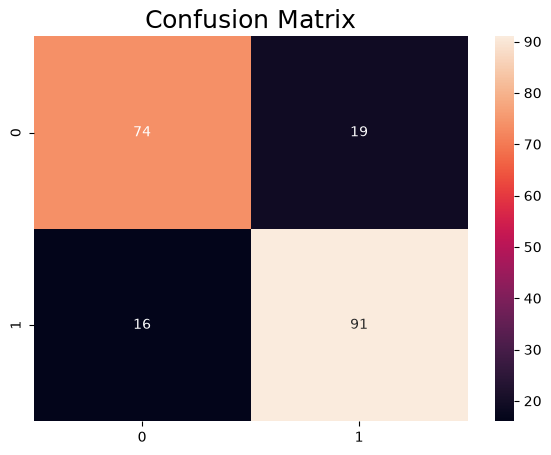

In [17]:
# Get the predictions from the classifier
y_pred = classifier.predict(X_test)

# Evaluate the classifier
class_report, conf_mat = evaluate_classification(y_test, y_pred)

---
# Exercise 2: Effect of Random Noise in Class Labels

We keep everything above (data loading, one-hot encoding, train/test split, and the baseline `GaussianNB` model) exactly as given. From here we only corrupt the **class label**, and only in `y_train` — `X_train`, `X_test`, and `y_test` stay fixed and untouched across all noise levels, so every run is trained on the same inputs and evaluated on the same clean benchmark.

In [18]:
def add_label_noise(y_train, noise_level=0.05, class_values=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    if class_values is None:
        class_values = y_train.unique()

    noisy_y = y_train.copy()
    n_noisy = int(len(y_train) * noise_level)
    if n_noisy == 0:
        return noisy_y

    noisy_indices = rng.choice(len(y_train), size=n_noisy, replace=False)
    noise = rng.choice(class_values, size=n_noisy)
    noisy_y.iloc[noisy_indices] = noise

    return noisy_y


def run_label_noise_experiment(X_train, X_test, y_train, y_test, noise_levels=None, seed=42):
    if noise_levels is None:
        noise_levels = [round(0.05 * i, 2) for i in range(20)]

    rng = np.random.default_rng(seed)
    class_values = y_train.unique()
    accuracies = {}

    for noise_level in noise_levels:
        y_train_noisy = add_label_noise(
            y_train, noise_level=noise_level, class_values=class_values, rng=rng
        )

        clf = GaussianNB()
        clf.fit(X_train, y_train_noisy)
        y_pred = clf.predict(X_test)  # test set (and its labels) stay untouched

        accuracies[noise_level] = accuracy_score(y_test, y_pred)

    return accuracies

In [19]:
import numpy as np
from sklearn.metrics import accuracy_score

def plot_label_noise(accuracies, baseline_acc=None):
    noise_levels = list(accuracies.keys())
    acc_values = list(accuracies.values())

    plt.figure(figsize=(8, 5))
    plt.plot(
        noise_levels,
        acc_values,
        marker="o",
        linewidth=2,
        markersize=6,
        color="#1f77b4",
        label="Model Accuracy",
    )

    if baseline_acc is not None:
        plt.axhline(
            baseline_acc, color="red", linestyle="--", alpha=0.7,
            label=f"Baseline (0% noise): {baseline_acc:.4f}"
        )

    plt.title("Impact of Class Label Noise on GaussianNB Accuracy", fontsize=13)
    plt.xlabel("Noise Level (Proportion of Training Labels Corrupted)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)

    y_min = min(min(acc_values), baseline_acc if baseline_acc is not None else 1.0) - 0.05
    y_max = max(max(acc_values), baseline_acc if baseline_acc is not None else 0.0) + 0.05
    plt.ylim(max(0.0, y_min), min(1.05, y_max))
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.gca().xaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(round(y*100))}%")
    )
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

Noise 0.00 | Accuracy: 0.8250
Noise 0.05 | Accuracy: 0.8300
Noise 0.10 | Accuracy: 0.8200
Noise 0.15 | Accuracy: 0.8200
Noise 0.20 | Accuracy: 0.8300
Noise 0.25 | Accuracy: 0.8200
Noise 0.30 | Accuracy: 0.8200
Noise 0.35 | Accuracy: 0.8150
Noise 0.40 | Accuracy: 0.8250
Noise 0.45 | Accuracy: 0.8200
Noise 0.50 | Accuracy: 0.8000
Noise 0.55 | Accuracy: 0.7550
Noise 0.60 | Accuracy: 0.7850
Noise 0.65 | Accuracy: 0.8150
Noise 0.70 | Accuracy: 0.7150
Noise 0.75 | Accuracy: 0.6300
Noise 0.80 | Accuracy: 0.5800
Noise 0.85 | Accuracy: 0.7350
Noise 0.90 | Accuracy: 0.7050
Noise 0.95 | Accuracy: 0.4750


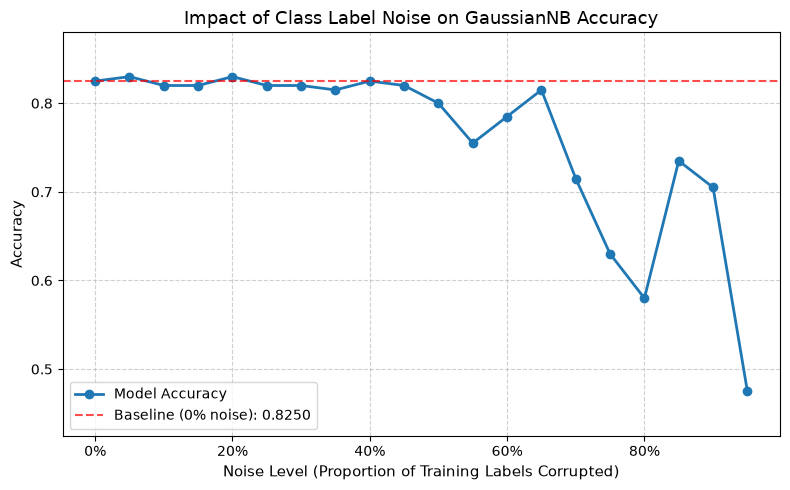

In [20]:
# Baseline accuracy from the classification report above ('accuracy' row)
from sklearn.metrics import accuracy_score
baseline_accuracy = accuracy_score(y_test, y_pred)

accuracies = run_label_noise_experiment(X_train, X_test, y_train, y_test)

for noise_level, acc in accuracies.items():
    print(f"Noise {noise_level:.2f} | Accuracy: {acc:.4f}")

plot_label_noise(accuracies, baseline_acc=baseline_accuracy)

## Takeaways

_TODO: fill in after running, following the same style as Exercise 1/3._